# Integral Distance

For signed barcodes encoded as signed measures $\mu,\nu$ on an oriented poset, define cumulative functions

$$
H_\mu(x)=\mu(\{u : u\le x\}),\qquad H_\nu(x)=\nu(\{u : u\le x\}).
$$

For Hilbert decomposition measures, this cumulative count is the
[Hilbert function](../invariants/hilbert_function.ipynb). Over a finite top
box $B$, `integral_distance` computes

$$
d_1(\mu,\nu)=\int_B |H_\mu(x)-H_\nu(x)|\,dx.
$$

In [1]:
import numpy as np
import multipers as mp
import matplotlib.pylab as plt
from multipers.distances import integral_distance
from multipers.data import noisy_annulus

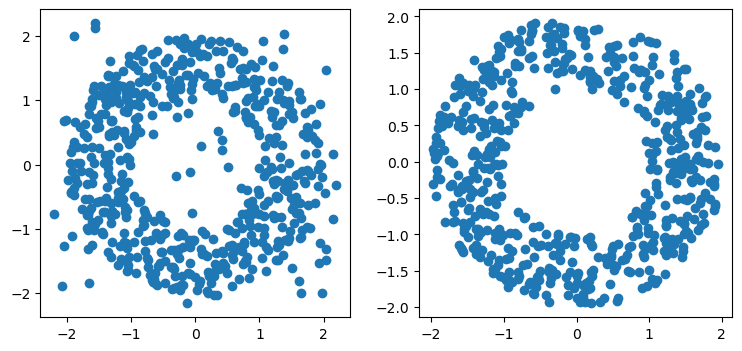

In [2]:
# Point clouds first. Same pipeline, different noise profile.
X = noisy_annulus(500,100)
Y = noisy_annulus(600,0)

fig, (a, b) = plt.subplots(1, 2, figsize=(9, 4))
a.scatter(*X.T)
a.set_aspect(1)

b.scatter(*Y.T)
b.set_aspect(1)
plt.show()

Build Delaunay-codensity filtrations for both point clouds. `DelaunayCodensity`
is the codensity specialization of the Delaunay lower-star construction; see
the [Delaunay Lowerstar filtrations](../filtrations/function_delaunay.ipynb)
notebook for construction details. We then take
[minimal presentations](../ops/minimal_presentations_resolutions.ipynb) in
degree 1.

In [3]:
f1 = mp.filtrations.DelaunayCodensity(points=X, bandwidth=.1, reduce_degree=1).minpres(1, full_resolution = 1)
f2 = mp.filtrations.DelaunayCodensity(points=Y, bandwidth=.1, reduce_degree=1).minpres(1, full_resolution = 1)

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


The [Hilbert signed measure](../invariants/signed_measure.ipynb) is the sparse
Möbius inversion whose cumulative lower-set sum is the Hilbert function.
Positive and negative masses encode generators and relations of the signed
decomposition.

/Users/dlapous/micromamba/envs/313/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


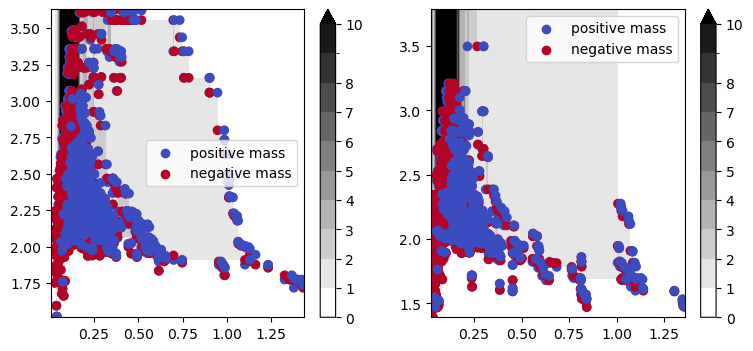

In [4]:
sm1 = mp.signed_measure(f1, invariant="hilbert")[0]
sm2 = mp.signed_measure(f2, invariant="hilbert")[0]

fig, (a, b) = plt.subplots(1, 2, figsize=(9, 4))
mp.invariants.hilbert_function(f1, plot=True, plot_kwargs={"ax": a})
mp.plots.plot_signed_measure(sm1, ax=a)
mp.invariants.hilbert_function(f2, plot=True, plot_kwargs={"ax": b})
mp.plots.plot_signed_measure(sm2, ax=b)
plt.show()

To visualize what is being integrated, first sample both Hilbert functions on
a common regular grid. The expression below is a Riemann-sum approximation of

$$
\int_B |H_\mu(x)-H_\nu(x)|\,dx.
$$

It multiplies the sum of pointwise absolute differences by one grid-cell
volume. This approximation depends on the chosen resolution; the next cell uses
`integral_distance`, which computes the integral directly from the signed
measures instead of sampling the Hilbert functions on a fixed grid.

np.float64(2.381275688307858)

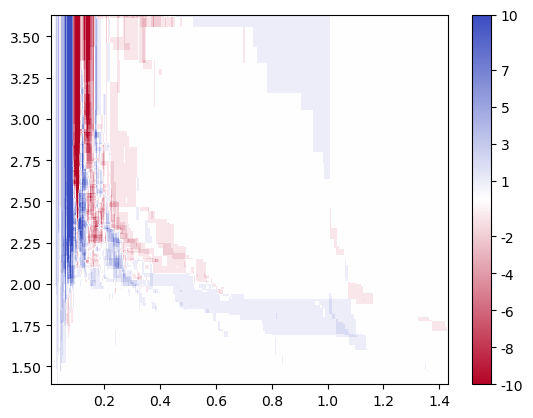

In [5]:
plt.figure()
grid = mp.grids.compute_grid_from_iterable((f1,f2), resolution=1000, strategy="regular")
h1 = mp.invariants.hilbert_function(f1, grid=grid)
h2 = mp.invariants.hilbert_function(f2, grid=grid)
mp.plots.plot_surface(grid,h2-h1)
np.abs(h1-h2).sum() * np.prod([g[1] - g[0] for g in grid])

In [6]:
# Real distance: convert to signed measures, then integrate.
mp.distances.integral_distance(
    sm1,
    sm2,
)

np.float64(2.378410840899117)